### Importing required modules

In [1]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

### Loading given dataset
The guide suggests to use `sklearn.datasets.load_digits` dataset with a total of 1797 images, in which we take 1437 for training in `X_train` and 360 for `X_test`.

### Understanding the dataset
The dataset consists of 1797 images of handwritten digits from 0 to 9 with each image labelled as the number it shows. The images are stored by flattening 8x8 pixel images into 64 one row values of numbers between 0 to 16. This is why the side of the whole dataset it (1797, 64) with each row having the data of an image. Each pixel value is between 0 to 16 and we normalize these to values between 0 to 1 by divding each value by 16.

At a time one row of the dataset goes into neural network for prediction or training. In practice we send data in batches to get an efficient training but here we can just send the data normally cause the dataset is small and dividing the data in batches is not expected to make any difference.

In [2]:
X, y = load_digits(return_X_y=True)
X = X / 16.0  # normalize pixel values (originally 0-16) to 0-1
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1437, 64) (1437,)
(360, 64) (360,)


### Architecture of our Neural Network
The architecture used here is 128 ---> 64 ---> 10 neurons in layer 1, layer 2 and layer 3 respectively. The input layer (X_train) size is (1437, 64) and the output is expected to be a probability distribution of probability of number being from 0 to 9 which yields 10 numbers so 10 neurons in the o/p layer.

*There maybe a better architecture then this but this was choosen on the basis of hit and trial for best accuracy.*

```
Layer 0 ---> Input layer (m, 64)

Layer 1 ---> 128 units | ReLU activation
              w1 = (64, 128), b1= (1, 128), n_w1 = 64*128 = 8192, n_b1 = 128

Layer 2 ---> 64 units | ReLU activation
              w2 = (128, 64), b2 = (1, 64), n_w2 = 128*64 = 8192, n_b2 = 64

Layer 3 ---> Output Layer | 10 units | softmax activation
              w3 = (64, 10), b3 = (1, 10), n_w3 = 64*10 = 640, n_b3 = 10

Total trainable params: n_w1 + n_w2 + n_w3 + n_b1 + n_b2 + n_b3 = 17226
        
```
While intializing weights in the cell below, we have used a particular kind of initialization called `Kaiming initialization(He initialization)`, because it helps to eliminate the chances of vanishing or exploding gradients in the networks that use ReLU activation in hidden layers. It works by initializing the weights on random by choosing random numbers from the Gaussian Distribution with mean = 0 and standard deviation = sqrt(2/n_in) where n_in is the number of values going in.

In [3]:
units_l1 = 128
units_l2 = 64
units_l3 = 10

# Initializing the values of weights and biases
w1 = np.random.randn(X_train.shape[1], units_l1) * np.sqrt(2/X_train.shape[1])
b1 = np.zeros((1, units_l1))

w2 = np.random.randn(units_l1, units_l2) * np.sqrt(2/units_l1)
b2 = np.zeros((1, units_l2))

w3 = np.random.randn(units_l2, units_l3) * np.sqrt(2/units_l2)
b3 = np.zeros((1, units_l3))

### Defining required functions
We can define functions to calculate and return things like relu, softmax and loss to make code more readable and efficient rather then using the formula at every place.

In [4]:
def relu(Z):
  A = np.maximum(Z, 0) # Returns a matrix by comparing each element for maximum placement.
  return A

def softmax(Z):
  row_max = np.max(Z, axis=1, keepdims=True)
  exp_Z = np.exp(Z - row_max) # We subtract row_max to make calculation efficient and it doesn't actually changes the result because it gets cancelled out
  row_sum = np.sum(exp_Z, axis = 1, keepdims=True)
  A = exp_Z / row_sum
  return A

def crossEntropyLoss(A, y):
  correct_prob = A[np.arange(len(y)), y]
  # print(correct_prob.shape)
  loss = -1 * np.sum(np.log(np.maximum(correct_prob, 1e-15)))
  loss /= len(y)
  return loss


### Gradient Checking
We can check if our backprop is working right by checking and comarping its output to gradient we calculate from the first principle. In the function below, we take a random of 3 values for each of the parameter, do a forward pass on w+eps and w-eps to determine L+ and L-, and by that we can then find out `dL/dw1 = (L+ - L-)/2*eps`, where is eps is some small value like `1e-5`. This gives us the gradient one way. Now we implement out backprop and find out gradient that way, then we can determine the max relative difference between those to se if our backpop is working or not becauses the gradient by first principle is always correct. The max relative difference should come out to be a small number like `1e-7` or smaller.

In [5]:
def loss_for_params(X, y, w1, b1, w2, b2, w3, b3):

  #Implementing a forward pass once to find loss for particular values of params
  Z1 = np.dot(X, w1) + b1
  A1 = relu(Z1)
  Z2 = np.dot(A1, w2) + b2
  A2 = relu(Z2)
  Z3 = np.dot(A2, w3) + b3
  A3 = softmax(Z3)
  return crossEntropyLoss(A3, y)

def gradient_check(param, grad_from_backprop, param_name, X, y, w1, b1, w2, b2, w3, b3, num_checks=3, eps=1e-5):
  print(f"\n--- Checking {param_name} (shape {param.shape}) ---")
  param = param.reshape(-1)
  grad = grad_from_backprop.reshape(-1)

  indices = np.random.choice(param.shape[0], num_checks, replace=False)

  max_rel_diff = 0
  for i in indices:
    original_value = param[i]

    param[i] = original_value + eps
    loss_plus = loss_for_params(X, y, w1, b1, w2, b2, w3, b3)

    param[i] = original_value - eps
    loss_minus = loss_for_params(X, y, w1, b1, w2, b2, w3, b3)

    param[i] = original_value

    grad_first_principal = (loss_plus - loss_minus) / (2 * eps)
    grad_backprop = grad[i]

    rel_diff = abs(grad_first_principal - grad_backprop) / max(abs(grad_first_principal) + abs(grad_backprop), 1e-8)
    max_rel_diff = max(max_rel_diff, rel_diff)

    if rel_diff < 1e-5:
      status="OK"
    else:
      status="MISMATCh"
    print(f"i = {i} | analytical = {grad_backprop:.8f} | numerical = {grad_first_principal:.8f} | rel_diff = {rel_diff:.2e} | {status}")

  print(f"Max relative difference for {param_name}: {max_rel_diff:.2e}")

X_check = X_train[:5]
y_check = y_train[:5]
m_check = y_check.shape[0]

Y_check = np.zeros((m_check, 10))
Y_check[np.arange(m_check), y_check] = 1

Z1 = np.dot(X_check, w1) + b1
A1 = relu(Z1)
Z2 = np.dot(A1, w2) + b2
A2 = relu(Z2)
Z3 = np.dot(A2, w3) + b3
A3 = softmax(Z3)

dZ3 = (1/m_check) * (A3 - Y_check)
dw3_check = np.dot(A2.T, dZ3)
db3_check = np.sum(dZ3, axis=0, keepdims=True)
dA2 = np.dot(dZ3, w3.T)

dZ2 = dA2 * (Z2 > 0)
dw2_check = np.dot(A1.T, dZ2)
db2_check = np.sum(dZ2, axis=0, keepdims=True)
dA1 = np.dot(dZ2, w2.T)

dZ1 = dA1 * (Z1 > 0)
dw1_check = np.dot(X_check.T, dZ1)
db1_check = np.sum(dZ1, axis=0, keepdims=True)


np.random.seed(42)  # to get the same result in result sampling
gradient_check(w1, dw1_check, "w1", X_check, y_check, w1, b1, w2, b2, w3, b3)
gradient_check(b1, db1_check, "b1", X_check, y_check, w1, b1, w2, b2, w3, b3)
gradient_check(w2, dw2_check, "w2", X_check, y_check, w1, b1, w2, b2, w3, b3)
gradient_check(b2, db2_check, "b2", X_check, y_check, w1, b1, w2, b2, w3, b3)
gradient_check(w3, dw3_check, "w3", X_check, y_check, w1, b1, w2, b2, w3, b3)
gradient_check(b3, db3_check, "b3", X_check, y_check, w1, b1, w2, b2, w3, b3)


--- Checking w1 (shape (64, 128)) ---
i = 5670 | analytical = 0.01795273 | numerical = 0.01795273 | rel_diff = 6.74e-10 | OK
i = 5369 | analytical = 0.00000000 | numerical = 0.00000000 | rel_diff = 0.00e+00 | OK
i = 2111 | analytical = 0.00000000 | numerical = 0.00000000 | rel_diff = 0.00e+00 | OK
Max relative difference for w1: 6.74e-10

--- Checking b1 (shape (1, 128)) ---
i = 7 | analytical = 0.00000000 | numerical = 0.00000000 | rel_diff = 0.00e+00 | OK
i = 109 | analytical = 0.01932281 | numerical = 0.01932281 | rel_diff = 3.50e-10 | OK
i = 8 | analytical = 0.08308932 | numerical = 0.08308932 | rel_diff = 5.05e-11 | OK
Max relative difference for b1: 3.50e-10

--- Checking w2 (shape (128, 64)) ---
i = 2241 | analytical = 0.00216823 | numerical = 0.00216823 | rel_diff = 3.54e-09 | OK
i = 876 | analytical = -0.00451835 | numerical = -0.00451835 | rel_diff = 1.63e-09 | OK
i = 7207 | analytical = -0.02985530 | numerical = -0.02985530 | rel_diff = 1.24e-10 | OK
Max relative difference

### Creating the training loop
In the training loop we will implement the main part, the forward pass, the backward pass, the gradient descent to change the values of weights and caluculate the loss and see it decreasing. We have to mainly calculate `dw1, dw2, dw3, db1, db2, db3` but to calculate these we have to calculate many more things along the way.

*dw1 represents dL/dw1 --> change of loss with respect to weights matrix of layer 1*

In [6]:
learning_rate = 0.1
epochs = 750
loss_history = []

m = y_train.shape[0]
Y = np.zeros((m ,10))
Y[np.arange(m), y_train] = 1


for epoch in range(epochs):
  #Forward pass to find the output at current weights and biases
  Z1 = np.dot(X_train, w1) + b1
  A1 = relu(Z1)

  Z2 = np.dot(A1, w2) + b2
  A2 = relu(Z2)

  Z3 = np.dot(A2, w3) + b3
  A3 = softmax(Z3)

  loss = crossEntropyLoss(A3, y_train)
  loss_history.append(loss)

  # Calculating the derivatives(gradients) with chain rule
  dZ3 = (1/m) * (A3 - Y)  # dZ3 = (m, 10)
  dw3 = np.dot(A2.T, dZ3) # dw3 = (64, 10)
  db3 = np.sum(dZ3, axis=0, keepdims=True) # db3 = (1, 10)
  dA2 = np.dot(dZ3, w3.T) # dA2 = (m, 64)

  dZ2 = dA2 * (Z2 > 0) # dZ2 = (m, 64)
  dw2 = np.dot(A1.T, dZ2) # dw2 = (128, 64)
  db2 = np.sum(dZ2, axis=0, keepdims=True) # db2 = (1, 64)
  dA1 = np.dot(dZ2, w2.T) # dA1 = (m, 128)

  dZ1 = dA1 * (Z1 > 0) # dZ1 = (m, 128)
  dw1 = np.dot(X_train.T, dZ1) # dw1 = (64, 128)
  db1 = np.sum(dZ1, axis=0, keepdims=True) # db1 = (1, 128)

  # Gradient descent step of updating parameters
  w1 -= learning_rate * dw1
  b1 -= learning_rate * db1

  w2 -= learning_rate * dw2
  b2 -= learning_rate * db2

  w3 -= learning_rate * dw3
  b3 -= learning_rate * db3


  if (epoch+1) % 50 == 0:
    preds = np.argmax(A3, axis=1)
    acc = np.mean(preds == y_train)
    print(f"Epoch: {epoch+1} | Loss: {loss:.4f} | Acc: {acc:.4f}")
    print(f"Weights: w1[5, 10]: {w1[5, 10]:.4f}, w2[1, 2]: {w2[1, 2]:.4f}, w3[1,2]: {w3[1,2]:.4f}")
    print(f"Biases: b1[0, 5]: {b1[0, 5]:.4f}, b2[0,2]: {b2[0,2]:.4f}, b3[0,9]: {b3[0,9]:.4f}")
    print("--------------------------------------------------------------------")



Epoch: 50 | Loss: 0.5624 | Acc: 0.8956
Weights: w1[5, 10]: -0.2170, w2[1, 2]: 0.0865, w3[1,2]: -0.1076
Biases: b1[0, 5]: 0.0000, b2[0,2]: 0.0002, b3[0,9]: -0.0114
--------------------------------------------------------------------
Epoch: 100 | Loss: 0.2829 | Acc: 0.9388
Weights: w1[5, 10]: -0.2272, w2[1, 2]: 0.0909, w3[1,2]: -0.1077
Biases: b1[0, 5]: 0.0000, b2[0,2]: 0.0008, b3[0,9]: -0.0069
--------------------------------------------------------------------
Epoch: 150 | Loss: 0.1939 | Acc: 0.9596
Weights: w1[5, 10]: -0.2324, w2[1, 2]: 0.0953, w3[1,2]: -0.1077
Biases: b1[0, 5]: 0.0000, b2[0,2]: 0.0015, b3[0,9]: -0.0052
--------------------------------------------------------------------
Epoch: 200 | Loss: 0.1498 | Acc: 0.9673
Weights: w1[5, 10]: -0.2361, w2[1, 2]: 0.0993, w3[1,2]: -0.1077
Biases: b1[0, 5]: 0.0000, b2[0,2]: 0.0018, b3[0,9]: -0.0049
--------------------------------------------------------------------
Epoch: 250 | Loss: 0.1229 | Acc: 0.9749
Weights: w1[5, 10]: -0.2393, 

### Checking the accuracy on test set
We can do the forwards pass once for the test set with the new trained parameters(weights + biases) and find out the accuracy it gives on the test set. If a model gives good accuracy on the training set and performs poorly on the test set, it shows that the model is overfitting which can happen if you increase the epochs too much, you can try setting the epoch of 1000 and see that the model accuracy on the test set drops whereas it will give a great accuracy on the training set(~99%).

In [7]:
Z1_test = np.dot(X_test, w1) + b1
A1_test = relu(Z1_test)

Z2_test = np.dot(A1_test, w2) + b2
A2_test = relu(Z2_test)

Z3_test = np.dot(A2_test, w3) + b3
A3_test = softmax(Z3_test)

test_pred = np.argmax(A3_test, axis=1)
test_acc = np.mean(test_pred == y_test)

print(f"Accuracy on test set: {test_acc * 100:.2f} %")

Accuracy on test set: 98.33 %


### Plotting graph and confusion matrix
We can plot the loss vs epoch curve for different learing rates and see which converges faster.

The confusion matrix shows the number of images classified correctly along the diagonal(in dark), the 1's in cells other then diagonal of the matrix show the digits misclassified.

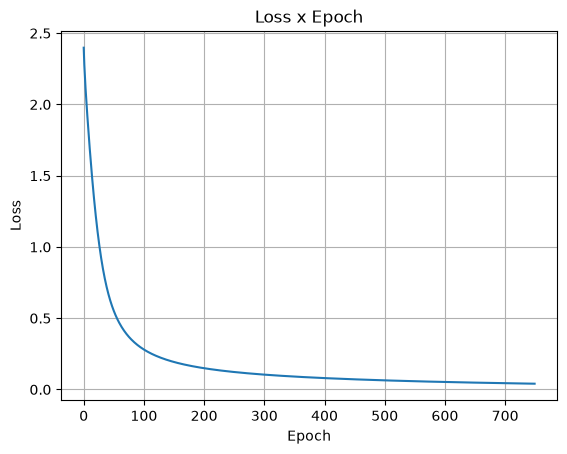

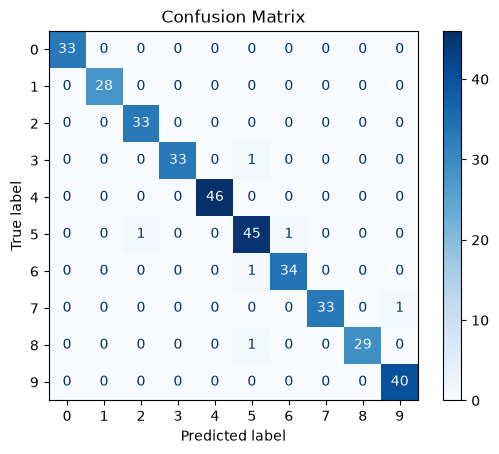

In [8]:
#Plotting the graph between loss and epochs to see the loss decreasing
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss x Epoch")
plt.grid(True)
plt.show()

cm = confusion_matrix(y_test, test_pred)
fig, ax = plt.subplots()
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

### Finding misclassified digits
We can find the misclassified digits, take 5 out of them and then use matplotlib to print the images. To show the images, we first take one row of 64 values, reshape it into 8x8 matrix, which is then the numerical representation of image, then we can use imshow function to show the matrix on gray scale. Seeing the image visually we can see why the model predicted it wrong.

Total misclassified: 6 out of 360


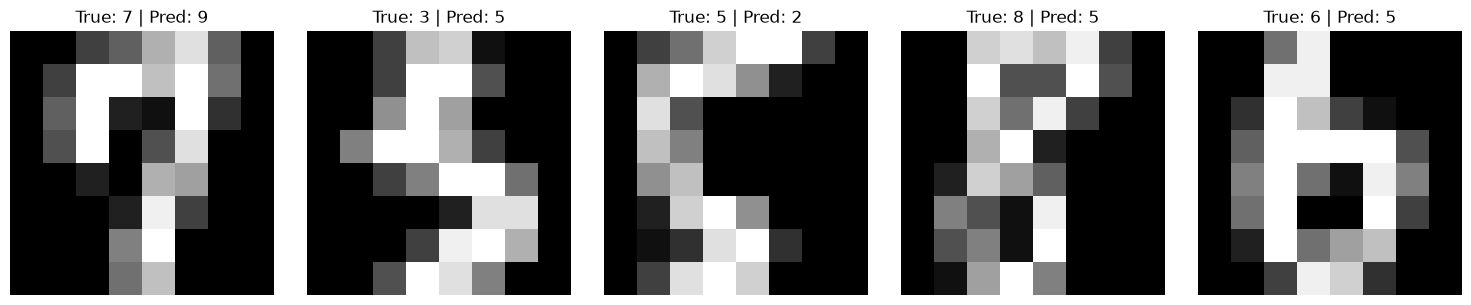

In [9]:
misclassified_idx = np.where(test_pred != y_test)[0]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_test)}")

sample_idx = misclassified_idx[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, idx in enumerate(sample_idx):
    image = X_test[idx].reshape(8, 8) # bringing the image back to 8x8 matrix
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"True: {y_test[idx]} | Pred: {test_pred[idx]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Saving the model
We can save the model here by saving the values of parameters in .npz file, we can later load the values of parameter from the file and give them to forward pass with same network architecture to make predictions. We don't train model everytime we have to make a prediction.

In [10]:
# The model almost gives a steady accuracy about ~97.50%, the max accuracy is recorded below
# Manually saving the one that gives the best accuracy, you can uncomment the last line of the code
# and save it when you get a better accuracy, till now its 98.0556%....
# Till now: best ==> 98.0556%

# np.savez('network_params.npz', w1=w1, w2=w2, w3=w3, b1=b1, b2=b2, b3=b3)